# Why does Runnable exist in LangChain?

Runnable is a standard interface that makes every component work the same way.

Before Runnable, different objects (LLMs, prompts, chains, parsers) had different methods. This made it harder to combine them.

With Runnable, everything follows the same pattern:

.invoke(),
.batch(),
.stream()

So you can connect components easily.

# Without Runnable

Imagine:

prompt.format()

llm.predict()

parser.parse()

Different methods for different objects.

You have to remember many APIs.

# With Runnable

Everything becomes:

result = runnable.invoke(input)

Example:

prompt.invoke(data)

llm.invoke(prompt_text)

parser.invoke(llm_output)

Same method everywhere.

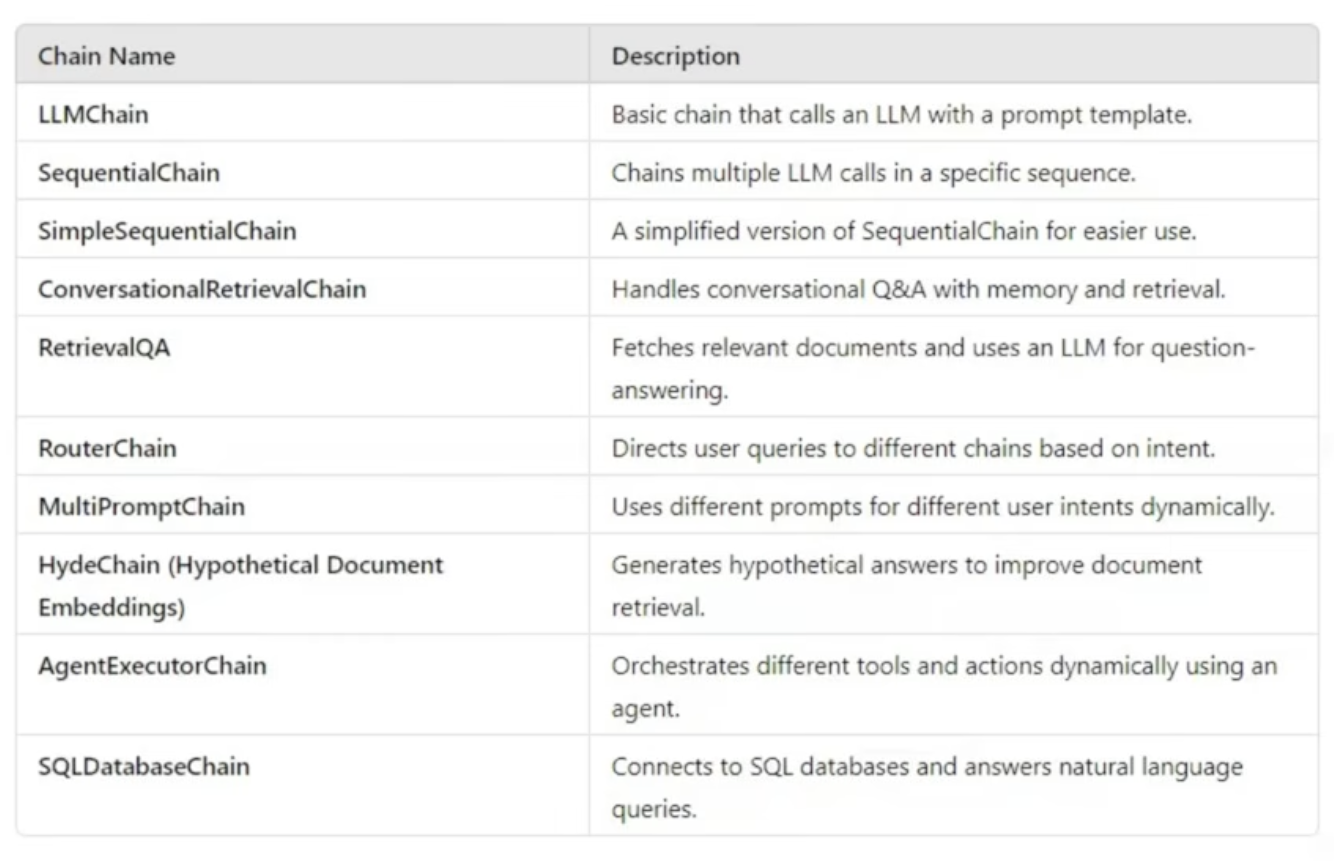

# Why is this useful?

1. Easy Chaining

You can connect components using |

chain = prompt | llm | parser

Instead of:

formatted = prompt.format(data)

response = llm.predict(formatted)

final = parser.parse(response)

2. Batch Processing

Run multiple inputs at once:

chain.batch([
    {"topic": "AI"},
    {"topic": "ML"}
])

3. Streaming

Get output token by token:

for chunk in chain.stream({"topic": "AI"}):
    print(chunk)

Useful for chat applications.

4. Parallel Execution

from langchain_core.runnables import RunnableParallel

chain = RunnableParallel({
    "summary": summary_chain,
    "keywords": keyword_chain
})

Both run together.

5. Easy Composition

You can mix:

Prompt Templates

LLMs

Output Parsers

Custom Python Functions

into one pipeline.

chain = prompt | llm | parser

Everything behaves like a Runnable.

# Problem with having too many Chain types in LangChain

1. Too many APIs to learn
2. Hard to combine chains

3. Limited flexibility
4. Code duplication
5. Difficult Streaming and Batching

Some chains supported:

stream()

Some didn't.

Some supported:

batch()

Some didn't.

Behavior was inconsistent.

# Too many Chain classes ka main problem ye tha ki sab alag-alag tarike se kaam karti thi aur ek dusre ke saath easily compatible nahi thi.


# Runnable ek standard interface hai jo batata hai ki koi component input lekar output produce kar sakta hai.

Simple words mein:

Runnable = koi bhi object jo run ho sakta hai aur .invoke() se output de sakta hai.

Examples of Runnables

1. Prompt Template

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    "Tell me about {topic}"
)

prompt ek Runnable hai.

prompt.invoke({"topic": "AI"})

2. LLM

from langchain_openai import ChatOpenAI

llm = ChatOpenAI()

llm bhi Runnable hai.

llm.invoke("What is AI?")

3. Output Parser

from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()

parser bhi Runnable hai.

parser.invoke(response)

# Why are they useful?

Kyuki sab Runnable hain, isliye unhe easily connect kar sakte hain:

# 1. .invoke() — Single Input

Ek input do, ek output milega.

chain.invoke({"topic": "AI"})

Output:

AI is the simulation of human intelligence...

# 2. .batch() — Multiple Inputs at Once

Agar tumhare paas bahut saare inputs hain, to ek-ek karke invoke() chalane ki jagah batch() use kar sakte ho.



# 3. .stream() — Output Piece by Piece

Normally LLM poora answer generate karke deta hai.

result = chain.invoke({"topic": "AI"})

User ko wait karna padega.

With stream:

for chunk in chain.stream({"topic": "AI"}):
    print(chunk)

Output aise aata hai:

AI

is

the

simulation

of

human

intelligence...

Ya token-by-token.

# Code

In [1]:
from abc import ABC, abstractmethod

In [2]:
class Runnable(ABC):

  @abstractmethod
  def invoke(input_data):
    pass

In [3]:
import random

class NakliLLM(Runnable):

  def __init__(self):
    print('LLM created')

  def invoke(self, prompt):
    response_list = [
        'Delhi is the capital of India',
        'IPL is a cricket league',
        'AI stands for Artificial Intelligence'
    ]

    return {'response': random.choice(response_list)}


  def predict(self, prompt):

    response_list = [
        'Delhi is the capital of India',
        'IPL is a cricket league',
        'AI stands for Artificial Intelligence'
    ]

    return {'response': random.choice(response_list)}

In [4]:
class NakliPromptTemplate(Runnable):

  def __init__(self, template, input_variables):
    self.template = template
    self.input_variables = input_variables

  def invoke(self, input_dict):
    return self.template.format(**input_dict)

  def format(self, input_dict):
    return self.template.format(**input_dict)

In [5]:
class NakliStrOutputParser(Runnable):

  def __init__(self):
    pass

  def invoke(self, input_data):
    return input_data['response']

In [6]:
class RunnableConnector(Runnable):

  def __init__(self, runnable_list):
    self.runnable_list = runnable_list

  def invoke(self, input_data):

    for runnable in self.runnable_list:
      input_data = runnable.invoke(input_data)

    return input_data

In [7]:
template = NakliPromptTemplate(
    template='Write a {length} poem about {topic}',
    input_variables=['length', 'topic']
)

In [8]:
llm = NakliLLM()

LLM created


In [9]:
parser = NakliStrOutputParser()

In [10]:
chain = RunnableConnector([template, llm, parser])

In [11]:
chain.invoke({'length':'long', 'topic':'india'})

'Delhi is the capital of India'

In [12]:
template1 = NakliPromptTemplate(
    template='Write a joke about {topic}',
    input_variables=['topic']
)

In [13]:
template2 = NakliPromptTemplate(
    template='Explain the following joke {response}',
    input_variables=['response']
)

In [14]:
llm = NakliLLM()

LLM created


In [15]:
parser = NakliStrOutputParser()

In [16]:
chain1 = RunnableConnector([template1, llm])

In [17]:
chain2 = RunnableConnector([template2, llm, parser])

In [18]:
final_chain = RunnableConnector([chain1, chain2])

In [19]:
final_chain.invoke({'topic':'cricket'})

'AI stands for Artificial Intelligence'